In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

In [2]:
data = {
    "Post_ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],

    "Post": [
        "AI is changing the future of technology",
        "Data Science is a trending career",
        "Machine Learning is very useful",
        "AI and Machine Learning are growing fast",
        "Technology makes life easier",
        "Data Science and AI are important skills",
        "Students are learning Python and AI",
        "Machine Learning helps businesses",
        "Python is popular for Data Science",
        "AI technology is trending"
    ]
}

df = pd.DataFrame(data)

In [3]:
print("Social Media Dataset:")
print(df)

Social Media Dataset:
   Post_ID                                      Post
0        1   AI is changing the future of technology
1        2         Data Science is a trending career
2        3           Machine Learning is very useful
3        4  AI and Machine Learning are growing fast
4        5              Technology makes life easier
5        6  Data Science and AI are important skills
6        7       Students are learning Python and AI
7        8         Machine Learning helps businesses
8        9        Python is popular for Data Science
9       10                 AI technology is trending


In [4]:
df["Clean_Text"] = df["Post"].str.lower()

In [5]:
df["Clean_Text"] = df["Clean_Text"].str.replace(
    r"[^\w\s]", "", regex=True
)

In [6]:
print("\nCleaned Text:")
print(df[["Post", "Clean_Text"]])


Cleaned Text:
                                       Post  \
0   AI is changing the future of technology   
1         Data Science is a trending career   
2           Machine Learning is very useful   
3  AI and Machine Learning are growing fast   
4              Technology makes life easier   
5  Data Science and AI are important skills   
6       Students are learning Python and AI   
7         Machine Learning helps businesses   
8        Python is popular for Data Science   
9                 AI technology is trending   

                                 Clean_Text  
0   ai is changing the future of technology  
1         data science is a trending career  
2           machine learning is very useful  
3  ai and machine learning are growing fast  
4              technology makes life easier  
5  data science and ai are important skills  
6       students are learning python and ai  
7         machine learning helps businesses  
8        python is popular for data science  
9      

In [7]:
all_text = " ".join(df["Clean_Text"])

In [8]:
words = all_text.split()


In [9]:
stop_words = {
    "is", "the", "of", "and", "are",
    "a", "to", "for", "in", "very",
    "on", "this", "it"
}

filtered_words = [
    word for word in words
    if word not in stop_words
]

In [10]:
filtered_words = [
    word for word in words
    if word not in stop_words
]

# Count words
word_count = Counter(filtered_words)

print("\nTrending Topics:")

for word, count in word_count.most_common(10):
    print(word, ":", count)



Trending Topics:
ai : 5
learning : 4
technology : 3
data : 3
science : 3
machine : 3
trending : 2
python : 2
changing : 1
future : 1


In [11]:
topics = [
    "ai",
    "data",
    "science",
    "machine",
    "learning",
    "python",
    "technology"
]

interest = {}

for topic in topics:
    interest[topic] = word_count[topic]

print("\nPublic Interests:")

for topic, count in interest.items():
    print(topic, ":", count)


Public Interests:
ai : 5
data : 3
science : 3
machine : 3
learning : 4
python : 2
technology : 3


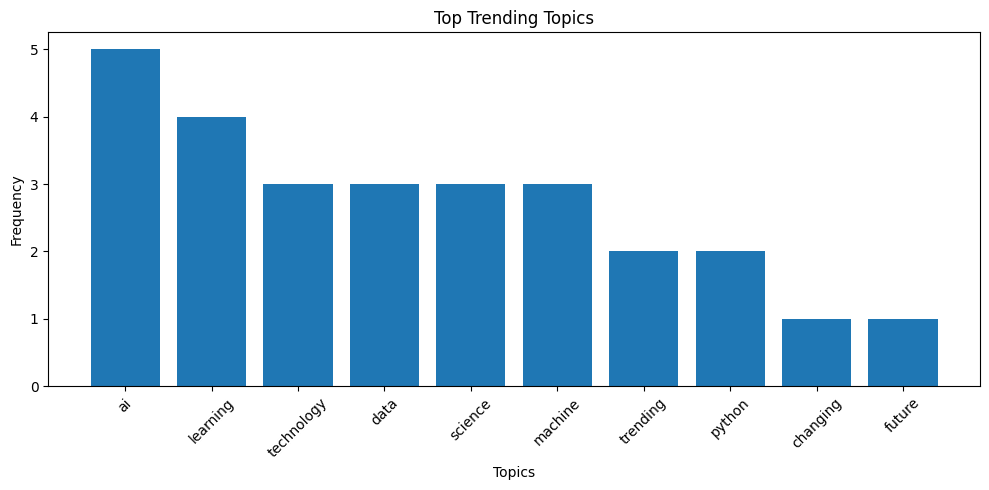

In [12]:
top_words = word_count.most_common(10)

words_list = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.figure(figsize=(10, 5))

plt.bar(words_list, counts)

plt.title("Top Trending Topics")
plt.xlabel("Topics")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


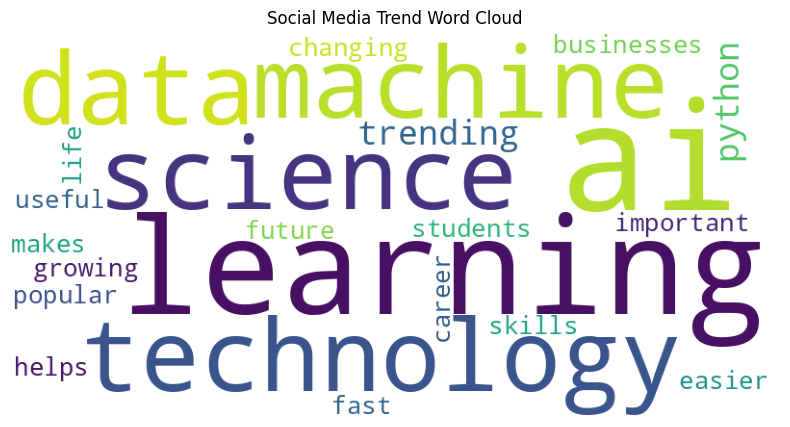

In [13]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(10, 5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Social Media Trend Word Cloud")

plt.show()